## Quantile Binning/Equal Frequency Binning:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import KBinsDiscretizer,OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df.shape

(891, 12)

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().mean()*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [6]:
df.drop(columns=['Cabin'],inplace=True)

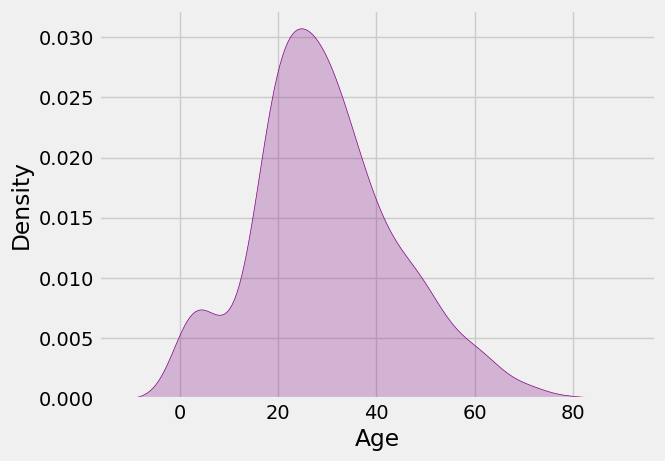

In [7]:
sns.kdeplot(df.Age,fill=True,color='purple')
plt.show()

In [8]:
df.Age.skew()

np.float64(0.38910778230082704)

In [9]:
df.dropna(subset=['Embarked'],inplace=True)

In [10]:
X=df.drop(columns=['Survived','Name','PassengerId','Ticket'])
Y=df['Survived']

In [11]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=10)

In [12]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
57,3,male,28.5,0,0,7.2292,C
717,2,female,27.0,0,0,10.5000,S
822,1,male,38.0,0,0,0.0000,S
397,2,male,46.0,0,0,26.0000,S
164,3,male,1.0,4,1,39.6875,S
...,...,...,...,...,...,...,...
370,1,male,25.0,1,0,55.4417,C
321,3,male,27.0,0,0,7.8958,S
528,3,male,39.0,0,0,7.9250,S
126,3,male,NaN,0,0,7.7500,Q


In [13]:
pipeline_age=Pipeline([
    ('imputer',SimpleImputer()),
    ('discretization',KBinsDiscretizer(n_bins=3,encode='ordinal',strategy='quantile'))
    ]
)

In [14]:
preprocessor=ColumnTransformer([
    ('age_pipeline',pipeline_age,['Age']),
    ('ohe',OneHotEncoder(drop='first',sparse_output=False),['Sex','Embarked']),
    ('scale',StandardScaler(),['Fare'])
],remainder='passthrough')

In [15]:
model=LogisticRegression()

In [16]:
pipeline1=Pipeline([
    ('preprocessor',preprocessor),
    ('model',model)
])

In [17]:
pipeline1.fit(X_train,Y_train)

C:\Users\khadk\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('age_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('discretization',
                                                                   KBinsDiscretizer(encode='ordinal',
                                                                                    n_bins=3))]),
                                                  ['Age']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Sex', 'Embarked']),
                                                 ('scale', StandardScaler(),
                                                  ['Fare'])])),
                ('model', LogisticRegression())])

In [18]:
y_pred=pipeline1.predict(X_test)

In [19]:
cross_val_score(pipeline1,X_train,Y_train,cv=5,scoring="accuracy").mean()

np.float64(0.7847926721166157)